# 🔍 Exploratory Data Analysis (EDA) — Online Retail Dataset

This notebook performs a **comprehensive EDA** on the Online Retail dataset, covering:

1. 📦 **Data Loading & Overview** — shape, dtypes, samples
2. 🕳️ **Missing Values Analysis** — heatmap & bar chart
3. 📊 **Univariate Analysis** — distribution of numerical columns
4. 🌍 **Categorical Analysis** — countries, products
5. 📈 **Time Series Analysis** — sales trends over time
6. 🔗 **Correlation & Bivariate** — relationships between features
7. 💰 **Revenue Analysis** — top customers, countries, products
8. 📋 **Summary & Key Insights**

---

In [1]:
# ──────────────────────────────────────────────
# Imports
# ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Style Configuration ──
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'font.family': 'sans-serif'
})

# Custom color palettes
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
          '#44BBA4', '#E94F37', '#393E41', '#D4A5A5', '#5C946E']
GRADIENT = sns.color_palette('coolwarm', 10)

print('✅ All libraries imported and style configured!')

✅ All libraries imported and style configured!


---
## 1️⃣ Data Loading & Overview

In [2]:
# Load the Online Retail dataset
dataset = pd.read_excel('./online_retail.xlsx')

print(f'Dataset Shape: {dataset.shape[0]:,} rows × {dataset.shape[1]} columns')
print(f'\nMemory Usage: {dataset.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print(f'\n── Column Information ──')
print(dataset.dtypes)
print(f'\n── First 5 Rows ──')
dataset.head()

Dataset Shape: 541,909 rows × 8 columns

Memory Usage: 141.48 MB

── Column Information ──
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

── First 5 Rows ──


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Last 5 rows & random sample
print('── Last 5 Rows ──')
display(dataset.tail())

print('\n── Random 5 Rows ──')
display(dataset.sample(5, random_state=42))

── Last 5 Rows ──


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France



── Random 5 Rows ──


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom


In [4]:
# Descriptive Statistics
print('── Numerical Summary ──')
display(dataset.describe())

print('\n── Categorical Summary ──')
display(dataset.describe(include='object'))

── Numerical Summary ──


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



── Categorical Summary ──


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


---
## 2️⃣ Missing Values Analysis

In [5]:
# Missing values summary table
missing = dataset.isnull().sum()
missing_pct = (missing / len(dataset) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Present Count': len(dataset) - missing,
    'Dtype': dataset.dtypes
}).sort_values('Missing Count', ascending=False)

print(f'Total cells: {dataset.shape[0] * dataset.shape[1]:,}')
print(f'Total missing: {missing.sum():,} ({missing.sum() / (dataset.shape[0] * dataset.shape[1]) * 100:.2f}%)')
print()
missing_df

Total cells: 4,335,272
Total missing: 136,534 (3.15%)



,Missing Count,Missing %,Present Count,Dtype
CustomerID,135080,24.93,406829,float64
Description,1454,0.27,540455,object
InvoiceNo,0,0.00,541909,object
StockCode,0,0.00,541909,object
Quantity,0,0.00,541909,int64
InvoiceDate,0,0.00,541909,datetime64[ns]
UnitPrice,0,0.00,541909,float64
Country,0,0.00,541909,object


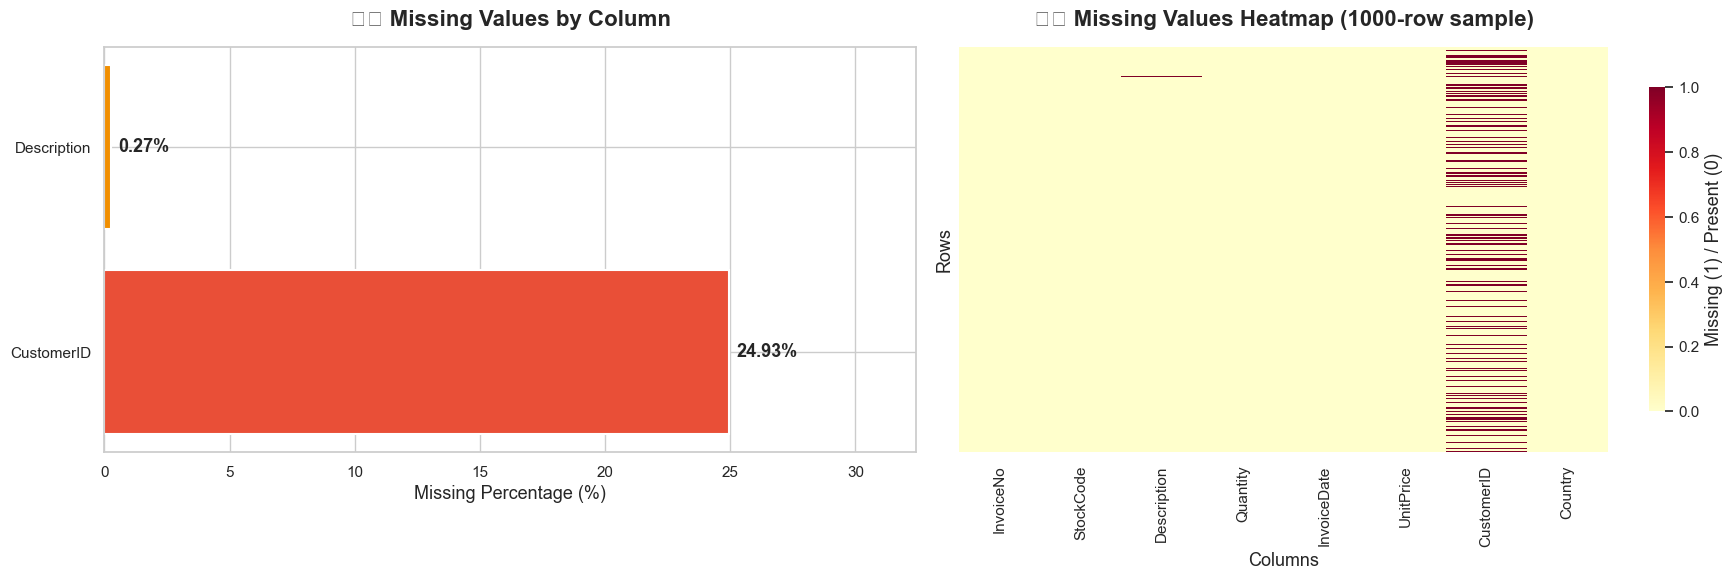

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Bar Chart: Missing Values by Column ──
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
bars = axes[0].barh(
    cols_with_missing.index,
    cols_with_missing['Missing %'],
    color=['#E94F37', '#F18F01'],
    edgecolor='white', linewidth=1.5
)
for bar, pct in zip(bars, cols_with_missing['Missing %']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{pct}%', va='center', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Missing Percentage (%)')
axes[0].set_title('🕳️ Missing Values by Column', pad=15)
axes[0].set_xlim(0, max(cols_with_missing['Missing %']) * 1.3)

# ── Heatmap: Missing Pattern ──
sample_for_heatmap = dataset.sample(min(1000, len(dataset)), random_state=42).sort_index()
sns.heatmap(
    sample_for_heatmap.isnull().astype(int),
    cbar_kws={'label': 'Missing (1) / Present (0)', 'shrink': 0.8},
    yticklabels=False, cmap='YlOrRd',
    ax=axes[1]
)
axes[1].set_title('🗺️ Missing Values Heatmap (1000-row sample)', pad=15)
axes[1].set_xlabel('Columns')
axes[1].set_ylabel('Rows')

plt.tight_layout()
plt.show()

---
## 3️⃣ Univariate Analysis — Numerical Distributions

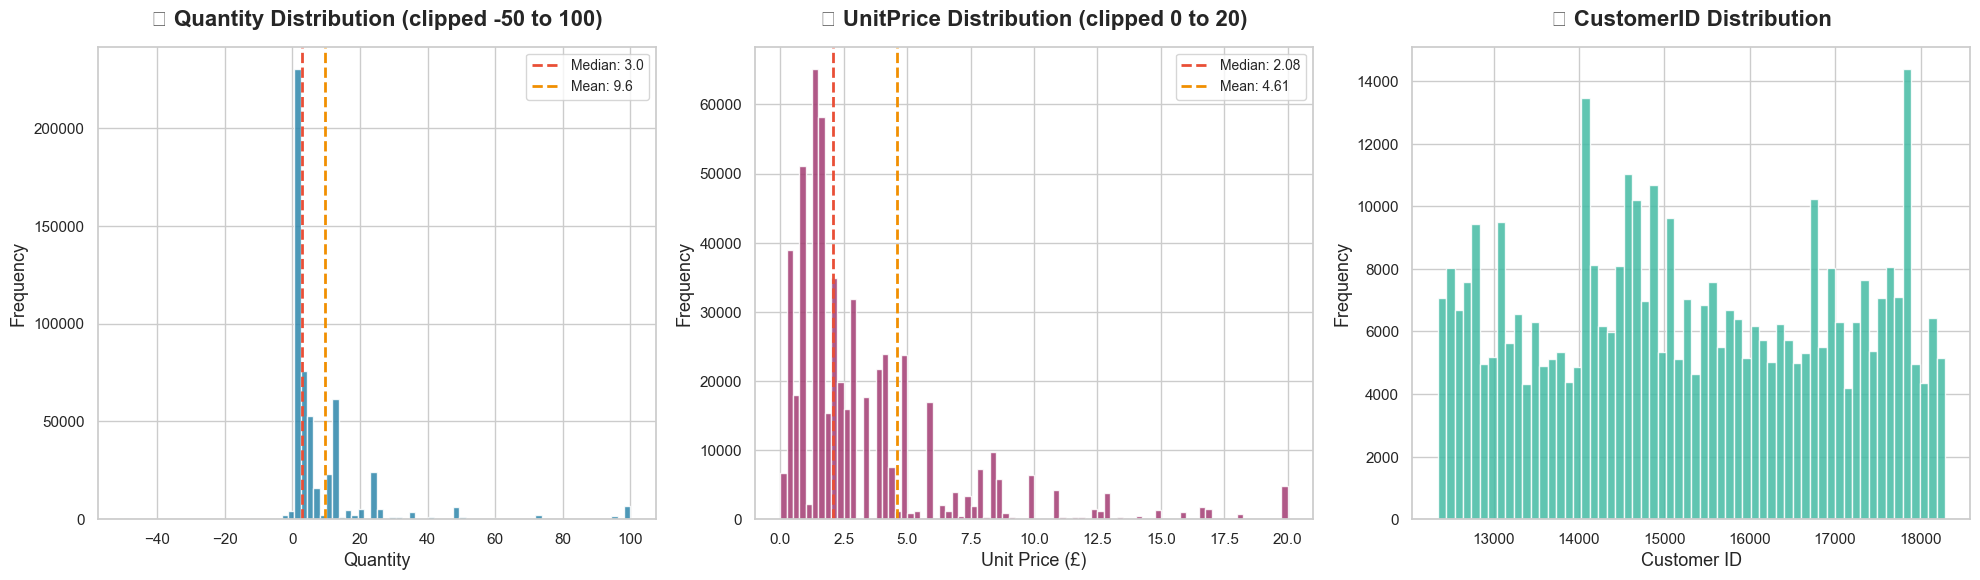

In [7]:
# ── Quantity Distribution (clipped for better visualization) ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram
qty_clipped = dataset['Quantity'].clip(-50, 100)
axes[0].hist(qty_clipped, bins=80, color='#2E86AB', edgecolor='white', alpha=0.85)
axes[0].axvline(dataset['Quantity'].median(), color='#E94F37', linestyle='--', lw=2, label=f'Median: {dataset["Quantity"].median()}')
axes[0].axvline(dataset['Quantity'].mean(), color='#F18F01', linestyle='--', lw=2, label=f'Mean: {dataset["Quantity"].mean():.1f}')
axes[0].set_title('📊 Quantity Distribution (clipped -50 to 100)', pad=15)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=10)

# UnitPrice Histogram
price_clipped = dataset['UnitPrice'].clip(0, 20)
axes[1].hist(price_clipped, bins=80, color='#A23B72', edgecolor='white', alpha=0.85)
axes[1].axvline(dataset['UnitPrice'].median(), color='#E94F37', linestyle='--', lw=2, label=f'Median: {dataset["UnitPrice"].median()}')
axes[1].axvline(dataset['UnitPrice'].mean(), color='#F18F01', linestyle='--', lw=2, label=f'Mean: {dataset["UnitPrice"].mean():.2f}')
axes[1].set_title('💰 UnitPrice Distribution (clipped 0 to 20)', pad=15)
axes[1].set_xlabel('Unit Price (£)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=10)

# CustomerID Distribution
cust_data = dataset['CustomerID'].dropna()
axes[2].hist(cust_data, bins=60, color='#44BBA4', edgecolor='white', alpha=0.85)
axes[2].set_title('👤 CustomerID Distribution', pad=15)
axes[2].set_xlabel('Customer ID')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

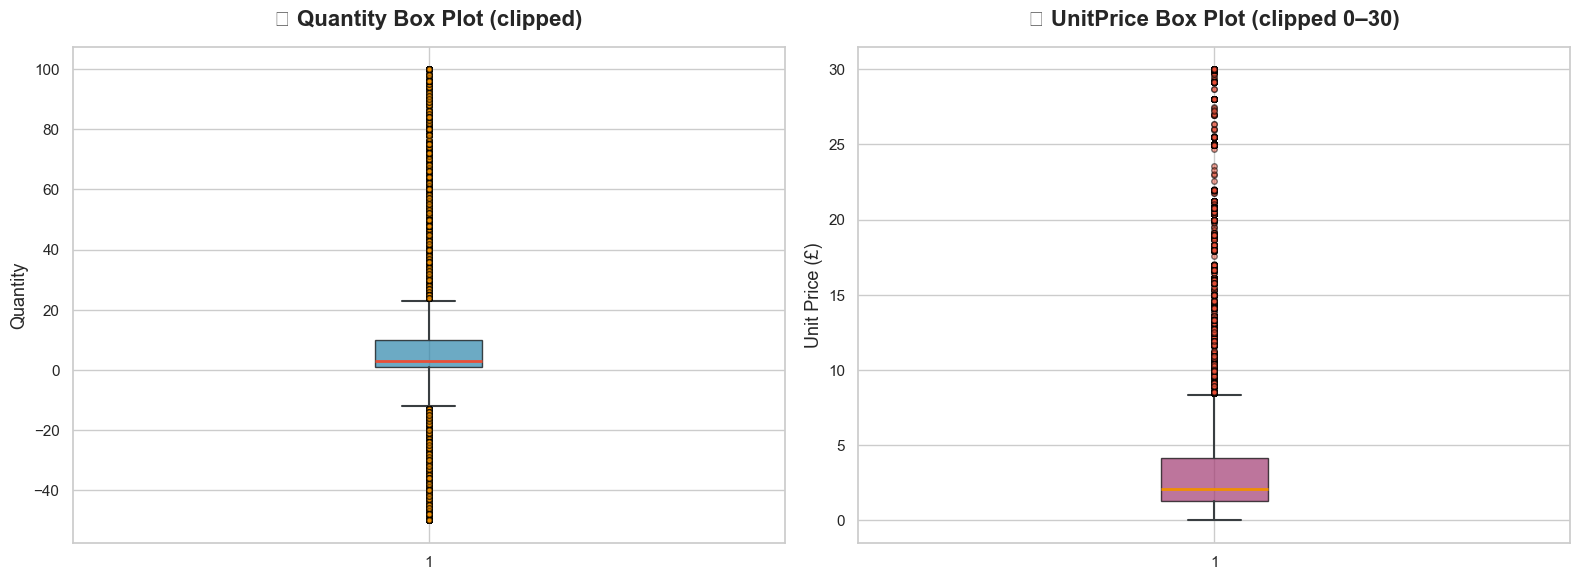

In [8]:
# ── Box Plots for Numerical Features ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Quantity Boxplot
bp1 = axes[0].boxplot(
    dataset['Quantity'].clip(-50, 100).dropna(),
    patch_artist=True, vert=True,
    boxprops=dict(facecolor='#2E86AB', alpha=0.7),
    medianprops=dict(color='#E94F37', linewidth=2),
    whiskerprops=dict(color='#393E41', linewidth=1.5),
    capprops=dict(color='#393E41', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#F18F01', markersize=4, alpha=0.5)
)
axes[0].set_title('📦 Quantity Box Plot (clipped)', pad=15)
axes[0].set_ylabel('Quantity')

# UnitPrice Boxplot
bp2 = axes[1].boxplot(
    dataset['UnitPrice'].clip(0, 30).dropna(),
    patch_artist=True, vert=True,
    boxprops=dict(facecolor='#A23B72', alpha=0.7),
    medianprops=dict(color='#F18F01', linewidth=2),
    whiskerprops=dict(color='#393E41', linewidth=1.5),
    capprops=dict(color='#393E41', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#E94F37', markersize=4, alpha=0.5)
)
axes[1].set_title('📦 UnitPrice Box Plot (clipped 0–30)', pad=15)
axes[1].set_ylabel('Unit Price (£)')

plt.tight_layout()
plt.show()

---
## 4️⃣ Categorical Analysis — Countries & Products

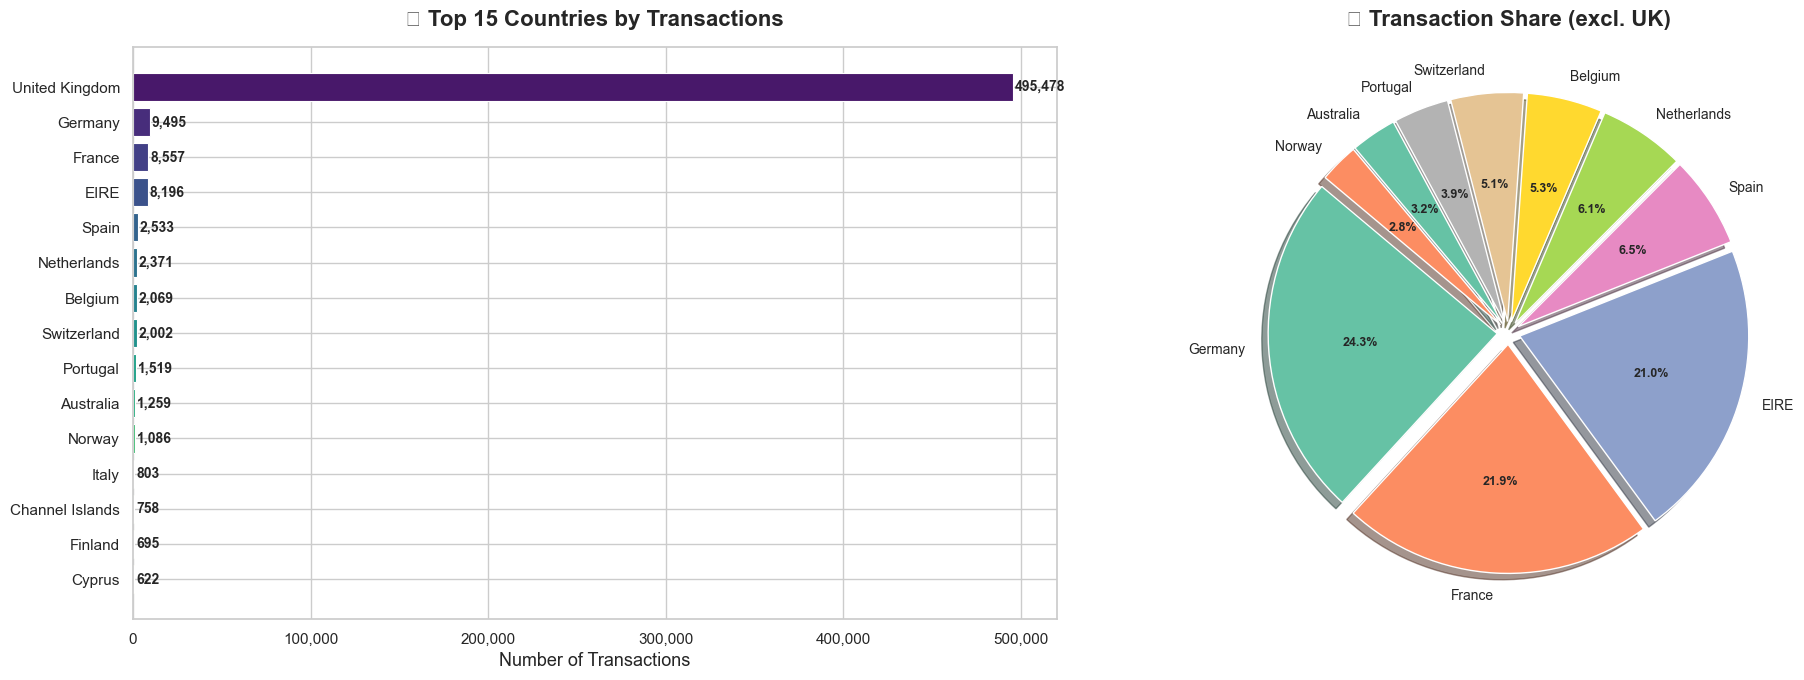

In [9]:
# ── Top 15 Countries by Transaction Count ──
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

country_counts = dataset['Country'].value_counts().head(15)
colors_bar = sns.color_palette('viridis', len(country_counts))

bars = axes[0].barh(country_counts.index[::-1], country_counts.values[::-1],
                     color=colors_bar[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, country_counts.values[::-1]):
    axes[0].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontweight='bold', fontsize=10)
axes[0].set_title('🌍 Top 15 Countries by Transactions', pad=15)
axes[0].set_xlabel('Number of Transactions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Top 15 Countries PIE (excluding UK for visibility) ──
country_no_uk = dataset[dataset['Country'] != 'United Kingdom']['Country'].value_counts().head(10)
explode = [0.05] * len(country_no_uk)
wedges, texts, autotexts = axes[1].pie(
    country_no_uk.values, labels=country_no_uk.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('Set2', len(country_no_uk)),
    explode=explode, shadow=True,
    textprops={'fontsize': 10}
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
axes[1].set_title('🥧 Transaction Share (excl. UK)', pad=15)

plt.tight_layout()
plt.show()

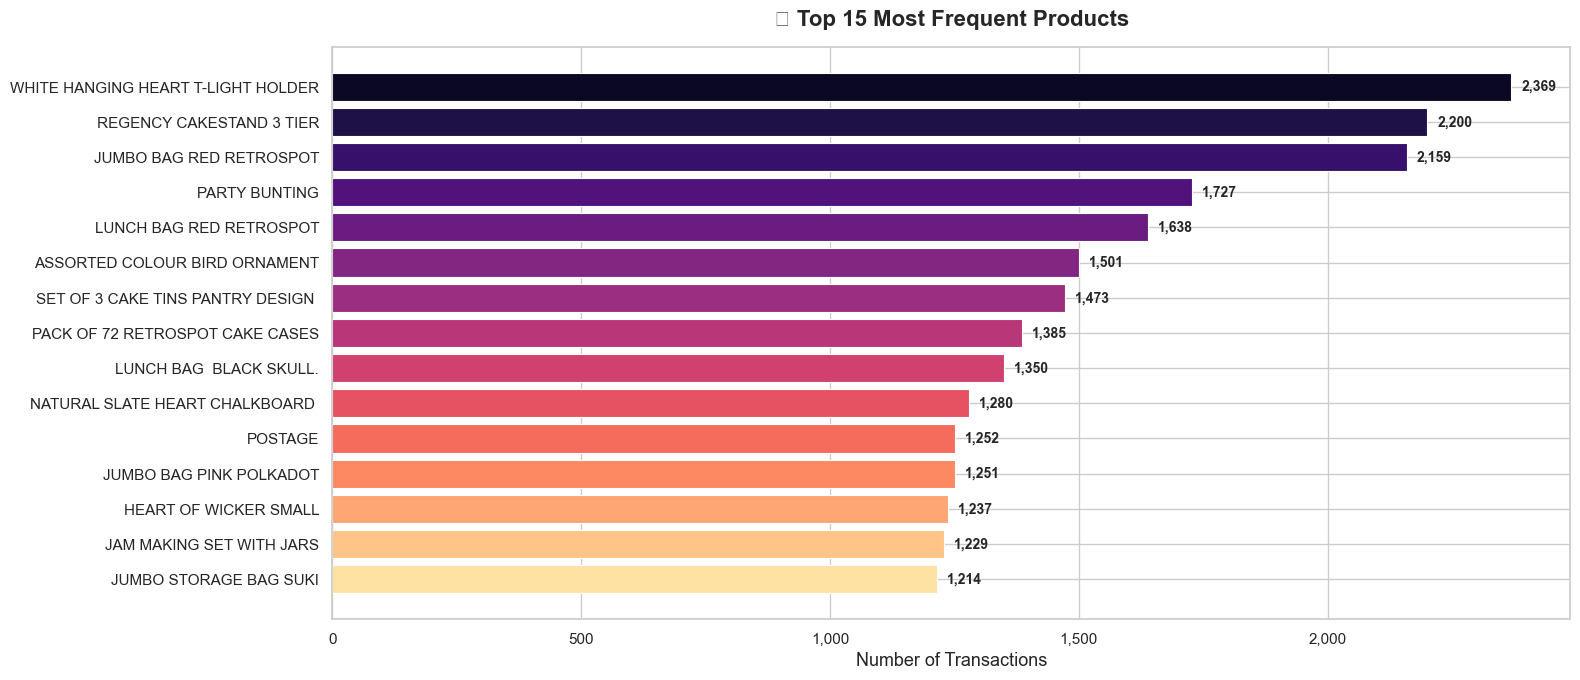

In [10]:
# ── Top 15 Most Frequent Products ──
fig, ax = plt.subplots(figsize=(16, 7))

top_products = dataset['Description'].value_counts().head(15)
colors_prod = sns.color_palette('magma', len(top_products))

bars = ax.barh(top_products.index[::-1], top_products.values[::-1],
               color=colors_prod[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, top_products.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold', fontsize=10)
ax.set_title('🛒 Top 15 Most Frequent Products', pad=15)
ax.set_xlabel('Number of Transactions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

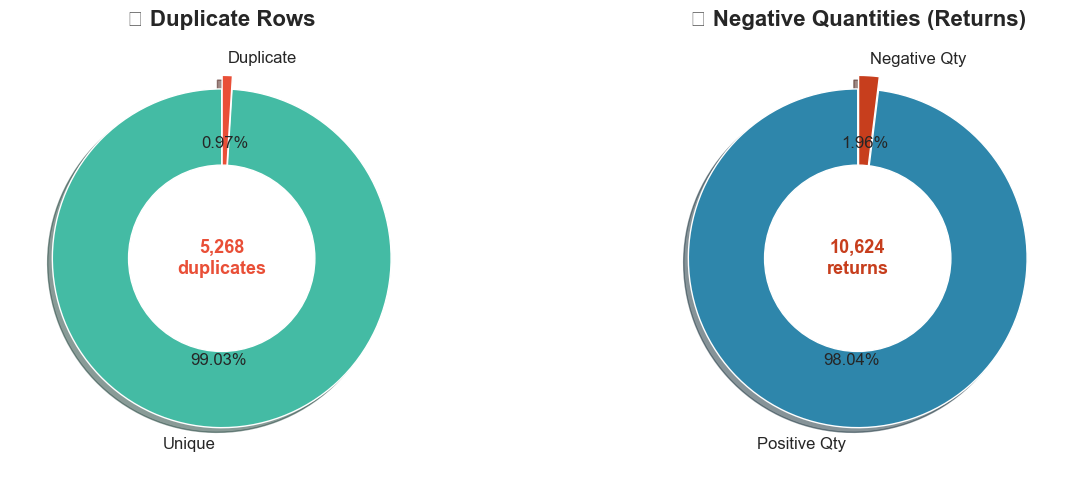

In [11]:
# ── Data Quality: Duplicates & Negative Quantities ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duplicates donut chart
dup_count = dataset.duplicated().sum()
non_dup = len(dataset) - dup_count
wedges, texts, autotexts = axes[0].pie(
    [non_dup, dup_count],
    labels=['Unique', 'Duplicate'],
    autopct='%1.2f%%', startangle=90,
    colors=['#44BBA4', '#E94F37'],
    explode=[0, 0.08], shadow=True,
    textprops={'fontsize': 12}
)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
axes[0].add_artist(centre_circle)
axes[0].text(0, 0, f'{dup_count:,}\nduplicates', ha='center', va='center',
             fontsize=13, fontweight='bold', color='#E94F37')
axes[0].set_title('📋 Duplicate Rows', pad=15)

# Negative quantity donut chart
neg_count = (dataset['Quantity'] < 0).sum()
pos_count = len(dataset) - neg_count
wedges2, texts2, autotexts2 = axes[1].pie(
    [pos_count, neg_count],
    labels=['Positive Qty', 'Negative Qty'],
    autopct='%1.2f%%', startangle=90,
    colors=['#2E86AB', '#C73E1D'],
    explode=[0, 0.08], shadow=True,
    textprops={'fontsize': 12}
)
centre_circle2 = plt.Circle((0, 0), 0.55, fc='white')
axes[1].add_artist(centre_circle2)
axes[1].text(0, 0, f'{neg_count:,}\nreturns', ha='center', va='center',
             fontsize=13, fontweight='bold', color='#C73E1D')
axes[1].set_title('❌ Negative Quantities (Returns)', pad=15)

plt.tight_layout()
plt.show()

---
## 5️⃣ Time Series Analysis — Sales Trends

In [12]:
# Create time-based features
dataset['InvoiceDate'] = pd.to_datetime(dataset['InvoiceDate'])
dataset['Year'] = dataset['InvoiceDate'].dt.year
dataset['Month'] = dataset['InvoiceDate'].dt.month
dataset['DayOfWeek'] = dataset['InvoiceDate'].dt.day_name()
dataset['Hour'] = dataset['InvoiceDate'].dt.hour
dataset['YearMonth'] = dataset['InvoiceDate'].dt.to_period('M')
dataset['TotalAmount'] = dataset['Quantity'] * dataset['UnitPrice']

print('✅ Time features created: Year, Month, DayOfWeek, Hour, YearMonth, TotalAmount')

✅ Time features created: Year, Month, DayOfWeek, Hour, YearMonth, TotalAmount


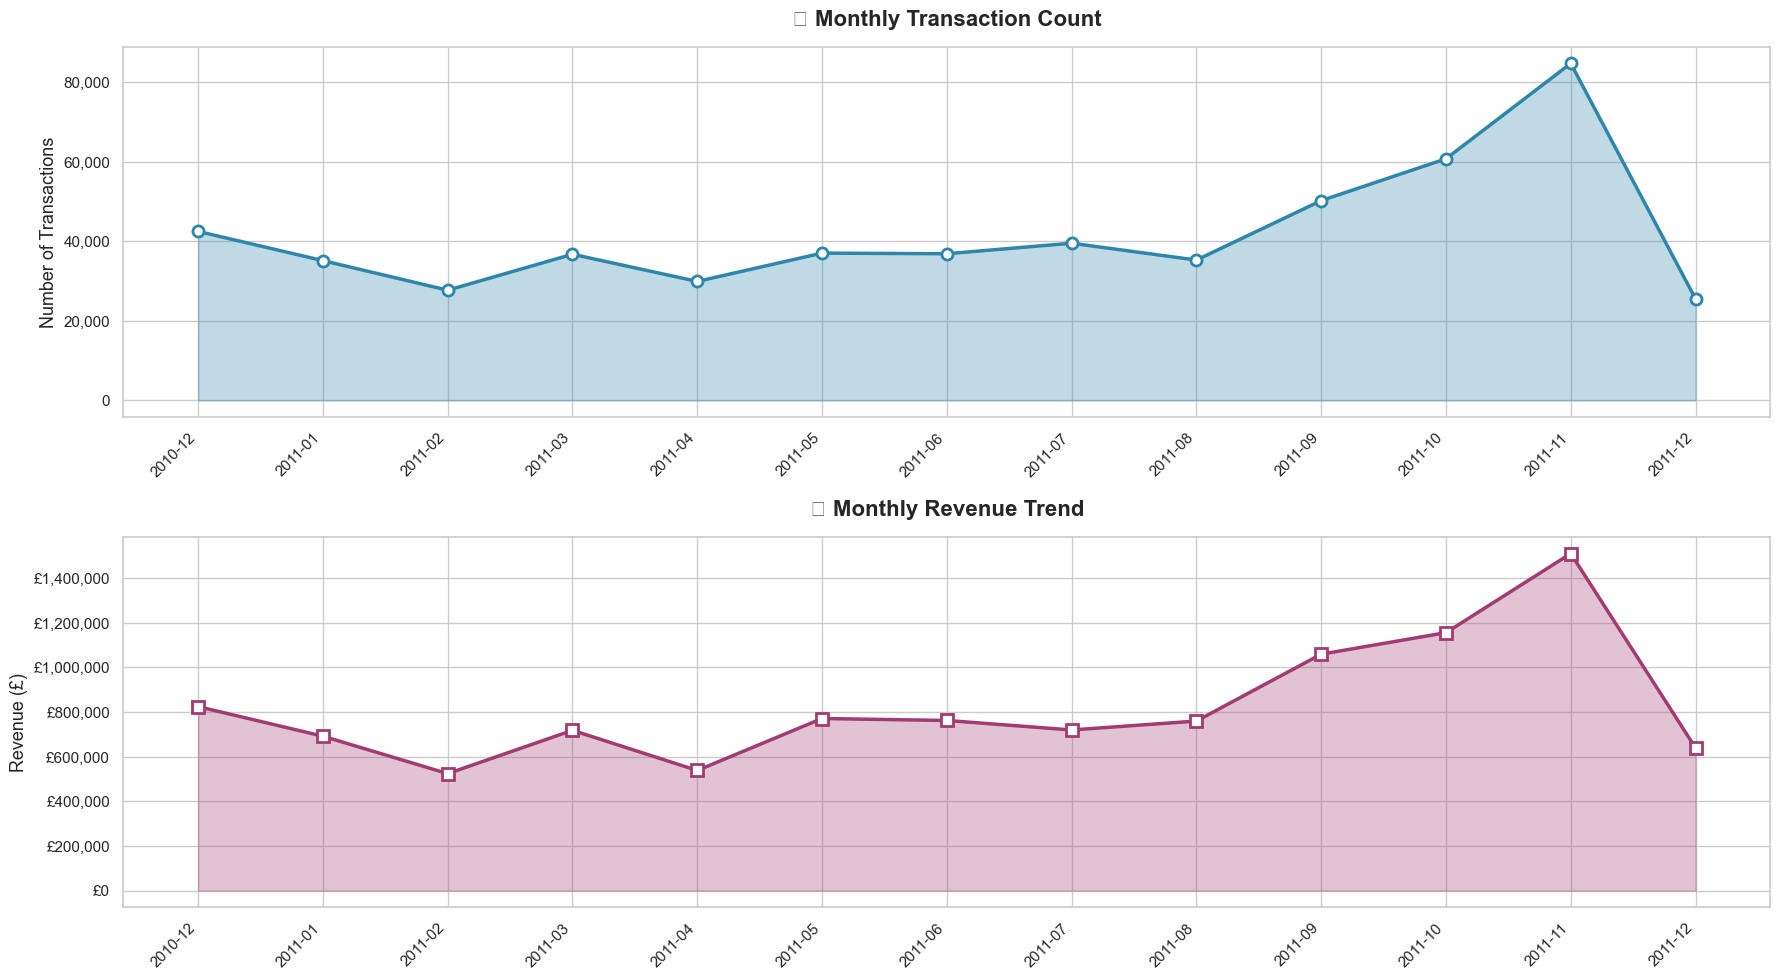

In [13]:
# ── Monthly Transaction Trend ──
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Transactions per month
monthly_txn = dataset.groupby('YearMonth').size()
x_labels = [str(p) for p in monthly_txn.index]
axes[0].fill_between(range(len(monthly_txn)), monthly_txn.values, alpha=0.3, color='#2E86AB')
axes[0].plot(range(len(monthly_txn)), monthly_txn.values, 'o-', color='#2E86AB',
             markersize=8, markerfacecolor='white', markeredgewidth=2, linewidth=2.5)
axes[0].set_xticks(range(len(x_labels)))
axes[0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0].set_title('📈 Monthly Transaction Count', pad=15)
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Revenue per month
monthly_rev = dataset[dataset['TotalAmount'] > 0].groupby('YearMonth')['TotalAmount'].sum()
x_labels_rev = [str(p) for p in monthly_rev.index]
axes[1].fill_between(range(len(monthly_rev)), monthly_rev.values, alpha=0.3, color='#A23B72')
axes[1].plot(range(len(monthly_rev)), monthly_rev.values, 's-', color='#A23B72',
             markersize=8, markerfacecolor='white', markeredgewidth=2, linewidth=2.5)
axes[1].set_xticks(range(len(x_labels_rev)))
axes[1].set_xticklabels(x_labels_rev, rotation=45, ha='right')
axes[1].set_title('💰 Monthly Revenue Trend', pad=15)
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.show()

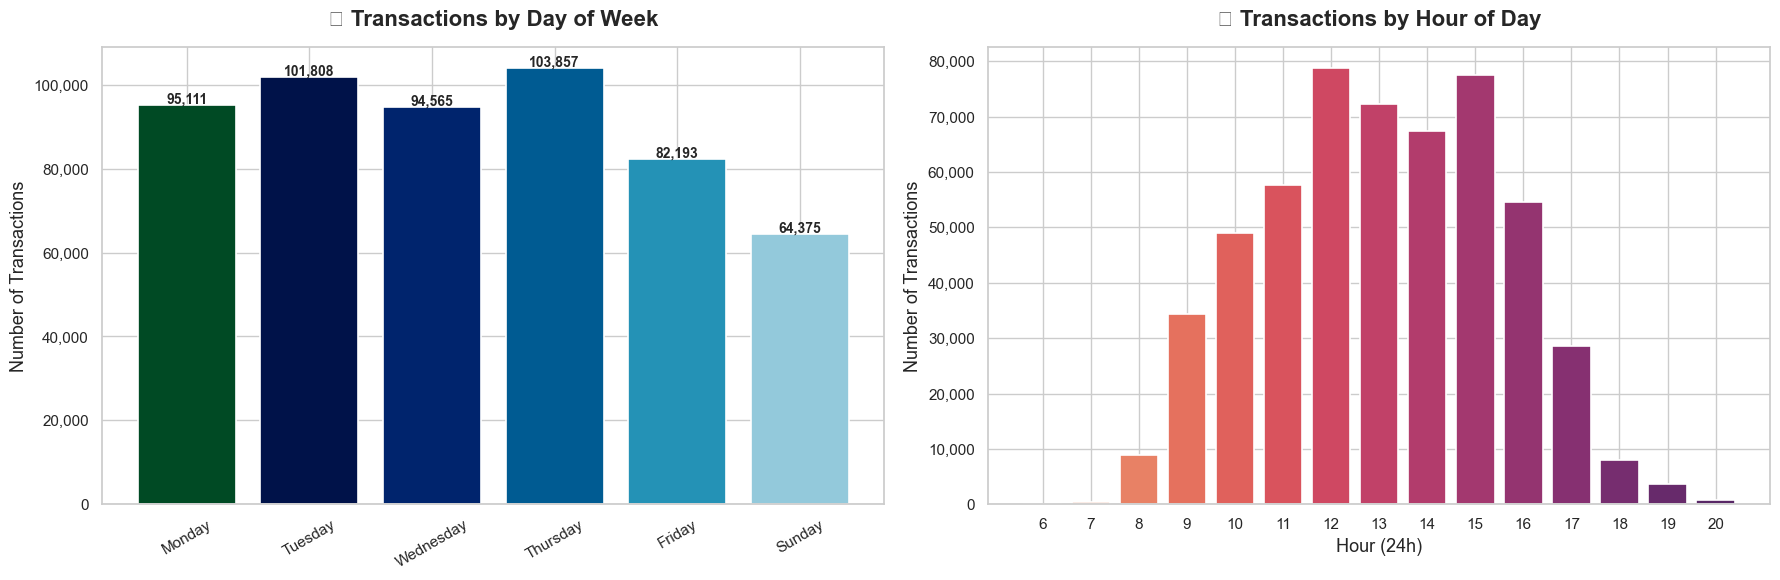

In [14]:
# ── Day of Week & Hour of Day Analysis ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
day_counts = dataset['DayOfWeek'].value_counts().reindex(day_order).dropna()
day_colors = sns.color_palette('ocean', len(day_counts))

bars = axes[0].bar(day_counts.index, day_counts.values, color=day_colors,
                    edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, day_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('📅 Transactions by Day of Week', pad=15)
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Hour of Day
hour_counts = dataset['Hour'].value_counts().sort_index()
hour_colors = sns.color_palette('flare', len(hour_counts))

bars2 = axes[1].bar(hour_counts.index, hour_counts.values, color=hour_colors,
                     edgecolor='white', linewidth=1.2, width=0.8)
axes[1].set_title('🕐 Transactions by Hour of Day', pad=15)
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xticks(hour_counts.index)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

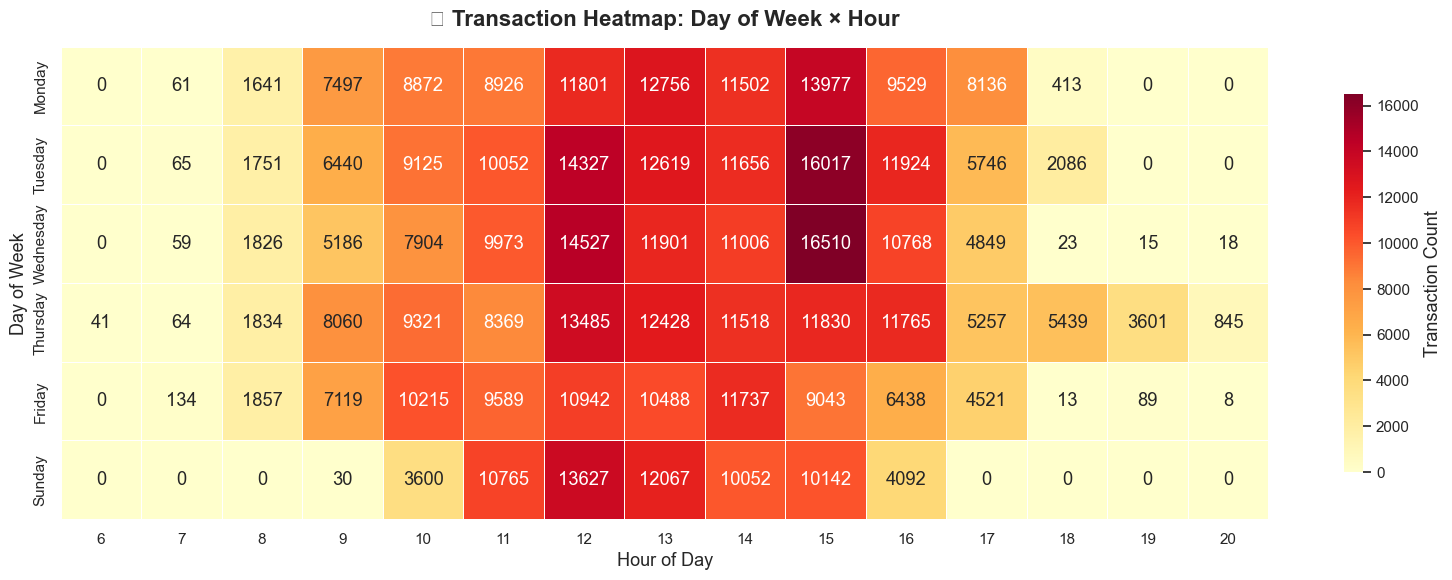

In [15]:
# ── Heatmap: Transactions by Day of Week × Hour ──
fig, ax = plt.subplots(figsize=(16, 6))

day_order_full = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
pivot = dataset.groupby(['DayOfWeek', 'Hour']).size().unstack(fill_value=0)
pivot = pivot.reindex(day_order_full).dropna(how='all')

sns.heatmap(
    pivot, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5,
    cbar_kws={'label': 'Transaction Count', 'shrink': 0.8},
    ax=ax
)
ax.set_title('🔥 Transaction Heatmap: Day of Week × Hour', pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

---
## 6️⃣ Correlation & Bivariate Analysis

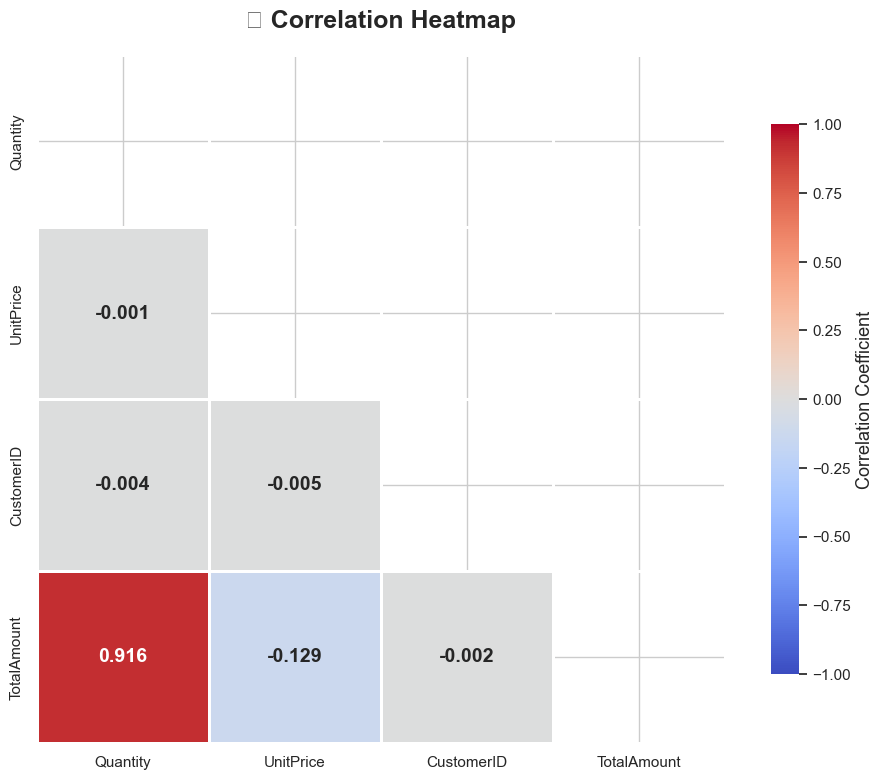

In [16]:
# ── Correlation Heatmap ──
fig, ax = plt.subplots(figsize=(10, 8))

numeric_cols = dataset[['Quantity', 'UnitPrice', 'CustomerID', 'TotalAmount']].dropna()
corr_matrix = numeric_cols.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='coolwarm', center=0, linewidths=2,
    square=True, vmin=-1, vmax=1,
    cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
    annot_kws={'fontsize': 14, 'fontweight': 'bold'},
    ax=ax
)
ax.set_title('🔗 Correlation Heatmap', pad=20, fontsize=18)

plt.tight_layout()
plt.show()

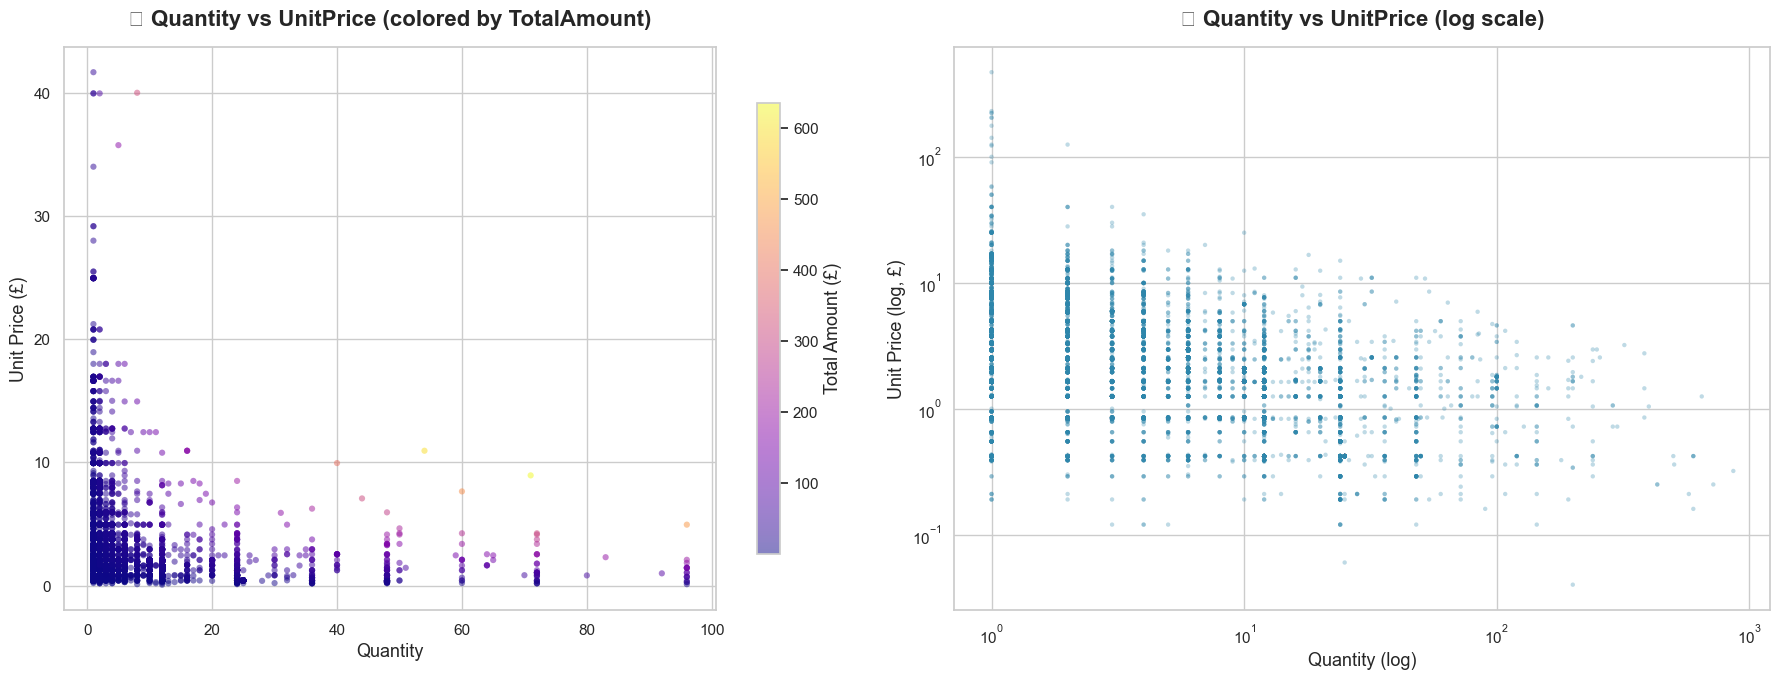

In [17]:
# ── Scatter Plot: Quantity vs UnitPrice ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Filtered view for clarity
clean = dataset[(dataset['Quantity'] > 0) & (dataset['Quantity'] < 100) &
                (dataset['UnitPrice'] > 0) & (dataset['UnitPrice'] < 50)].sample(5000, random_state=42)

scatter = axes[0].scatter(
    clean['Quantity'], clean['UnitPrice'],
    c=clean['TotalAmount'], cmap='plasma',
    alpha=0.5, s=20, edgecolors='none'
)
plt.colorbar(scatter, ax=axes[0], label='Total Amount (£)', shrink=0.8)
axes[0].set_title('🔵 Quantity vs UnitPrice (colored by TotalAmount)', pad=15)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Unit Price (£)')

# Log-scale scatter for full range
clean_full = dataset[(dataset['Quantity'] > 0) & (dataset['UnitPrice'] > 0)].sample(10000, random_state=42)
axes[1].scatter(
    clean_full['Quantity'], clean_full['UnitPrice'],
    alpha=0.3, s=10, color='#2E86AB', edgecolors='none'
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('🔬 Quantity vs UnitPrice (log scale)', pad=15)
axes[1].set_xlabel('Quantity (log)')
axes[1].set_ylabel('Unit Price (log, £)')

plt.tight_layout()
plt.show()

---
## 7️⃣ Revenue Analysis — Top Customers, Countries & Products

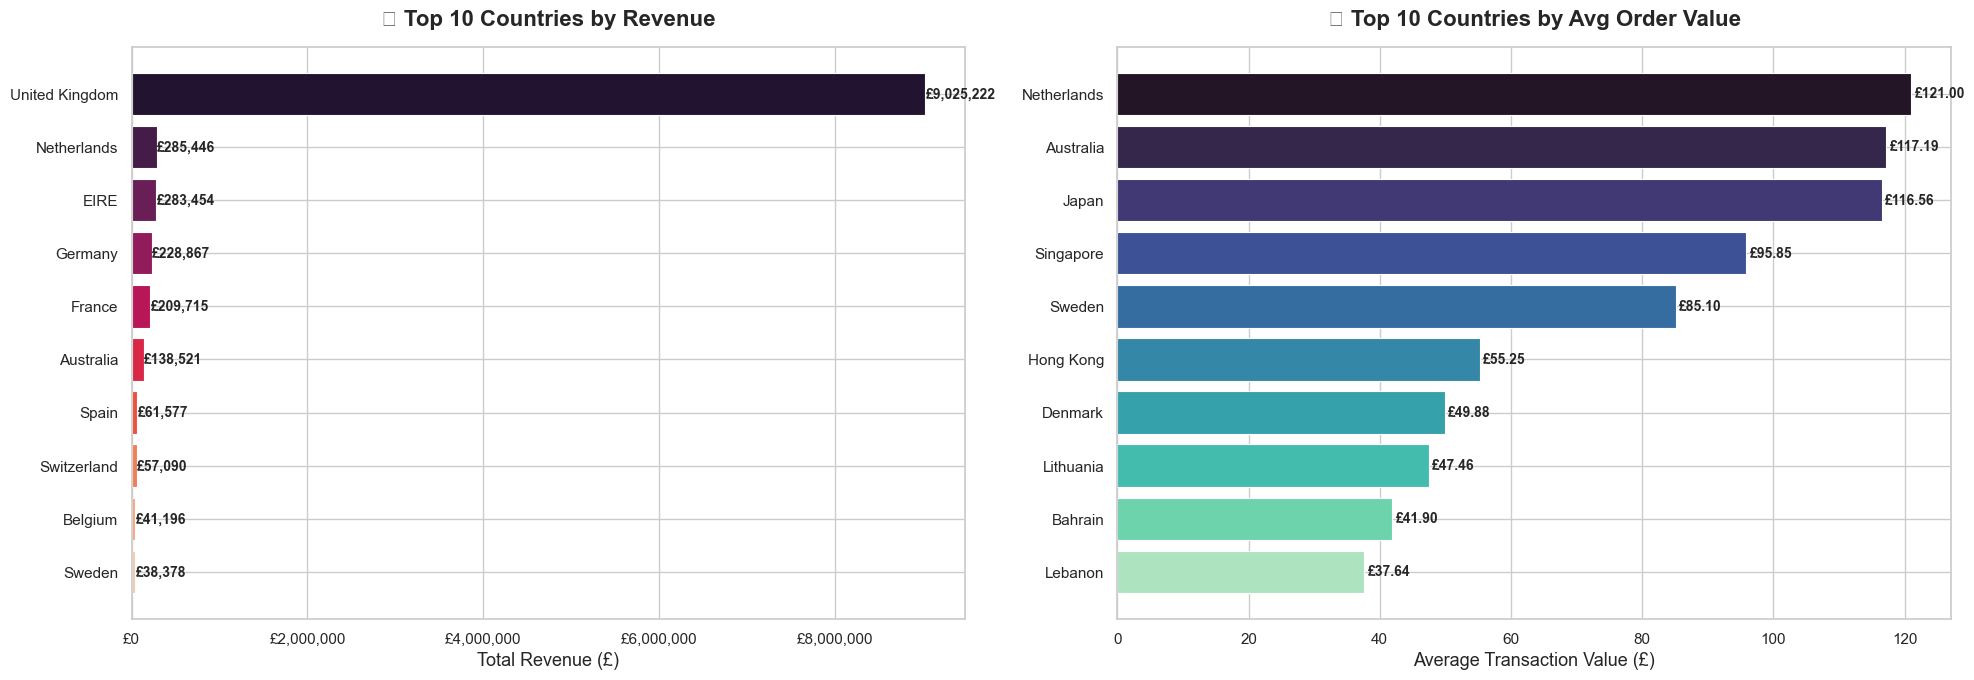

In [18]:
# ── Revenue by Country (Top 10, excluding negative amounts) ──
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

positive_txns = dataset[dataset['TotalAmount'] > 0]

# Top 10 countries by revenue
country_revenue = positive_txns.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
colors_rev = sns.color_palette('rocket', len(country_revenue))

bars = axes[0].barh(country_revenue.index[::-1], country_revenue.values[::-1],
                     color=colors_rev[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, country_revenue.values[::-1]):
    axes[0].text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
                 f'£{val:,.0f}', va='center', fontweight='bold', fontsize=10)
axes[0].set_title('🌍 Top 10 Countries by Revenue', pad=15)
axes[0].set_xlabel('Total Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Top 10 countries by avg order value
country_avg = positive_txns.groupby('Country')['TotalAmount'].mean().sort_values(ascending=False).head(10)
bars2 = axes[1].barh(country_avg.index[::-1], country_avg.values[::-1],
                      color=sns.color_palette('mako', len(country_avg))[::-1],
                      edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, country_avg.values[::-1]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'£{val:,.2f}', va='center', fontweight='bold', fontsize=10)
axes[1].set_title('💎 Top 10 Countries by Avg Order Value', pad=15)
axes[1].set_xlabel('Average Transaction Value (£)')

plt.tight_layout()
plt.show()

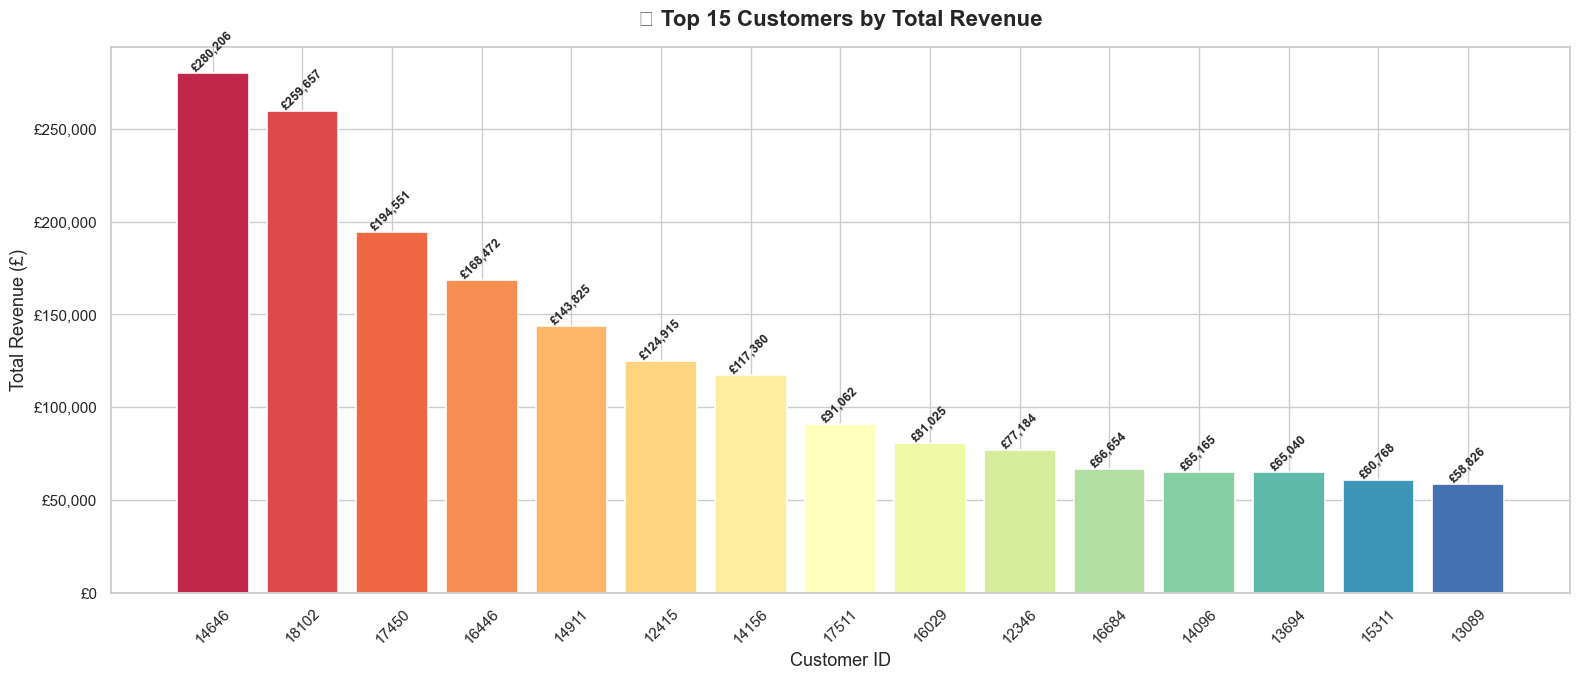

In [19]:
# ── Top 15 Customers by Revenue ──
fig, ax = plt.subplots(figsize=(16, 7))

cust_revenue = positive_txns.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(15)
cust_revenue.index = cust_revenue.index.astype(int).astype(str)

colors_cust = sns.color_palette('Spectral', len(cust_revenue))
bars = ax.bar(cust_revenue.index, cust_revenue.values, color=colors_cust,
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, cust_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'£{val:,.0f}', ha='center', fontweight='bold', fontsize=9, rotation=45)
ax.set_title('🏆 Top 15 Customers by Total Revenue', pad=15)
ax.set_xlabel('Customer ID')
ax.set_ylabel('Total Revenue (£)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.show()

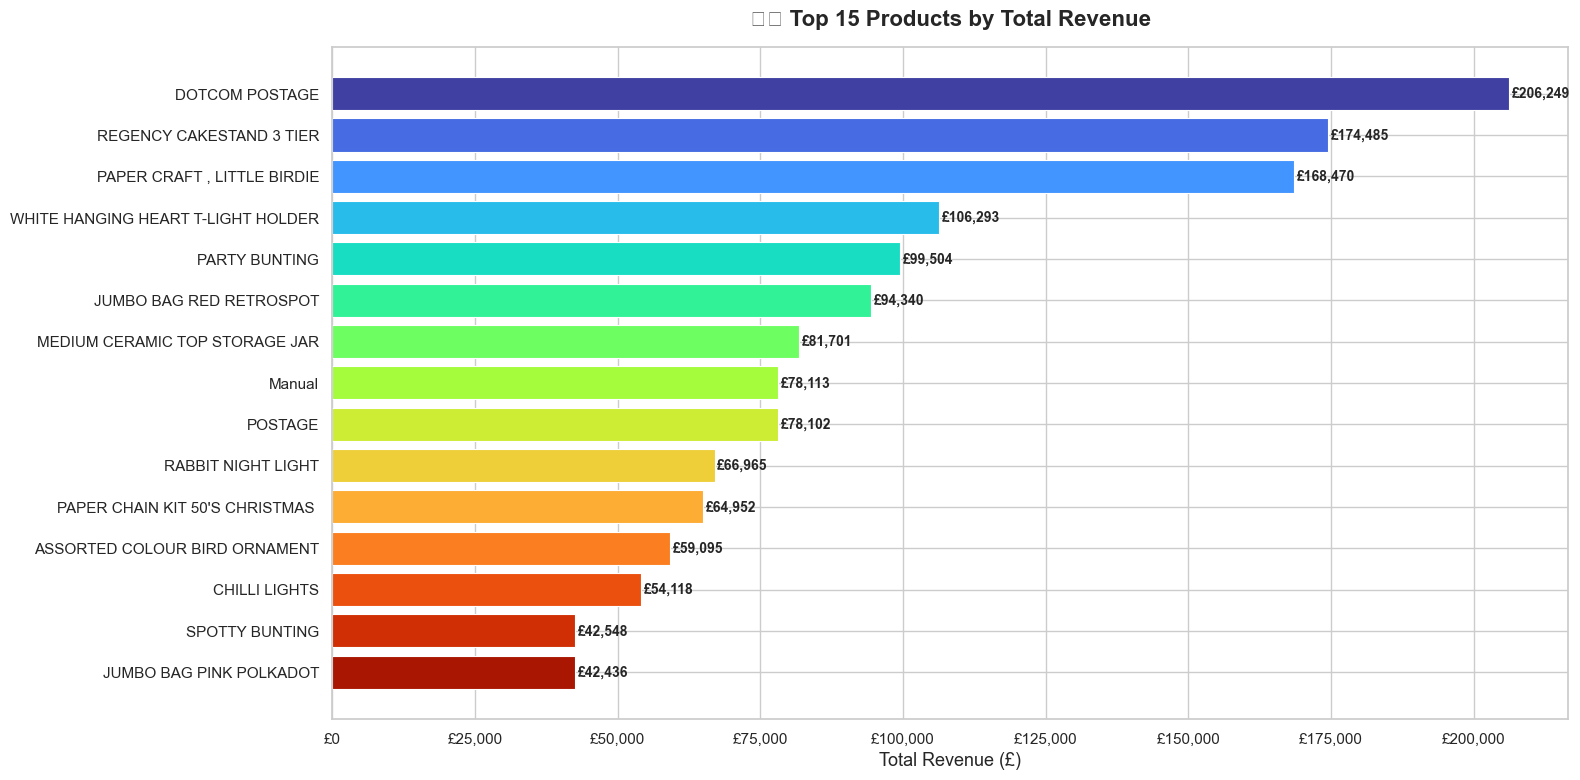

In [20]:
# ── Top 15 Products by Revenue ──
fig, ax = plt.subplots(figsize=(16, 8))

product_revenue = positive_txns.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(15)
colors_pr = sns.color_palette('turbo', len(product_revenue))

bars = ax.barh(product_revenue.index[::-1], product_revenue.values[::-1],
               color=colors_pr[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, product_revenue.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontweight='bold', fontsize=10)
ax.set_title('🛍️ Top 15 Products by Total Revenue', pad=15)
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.show()

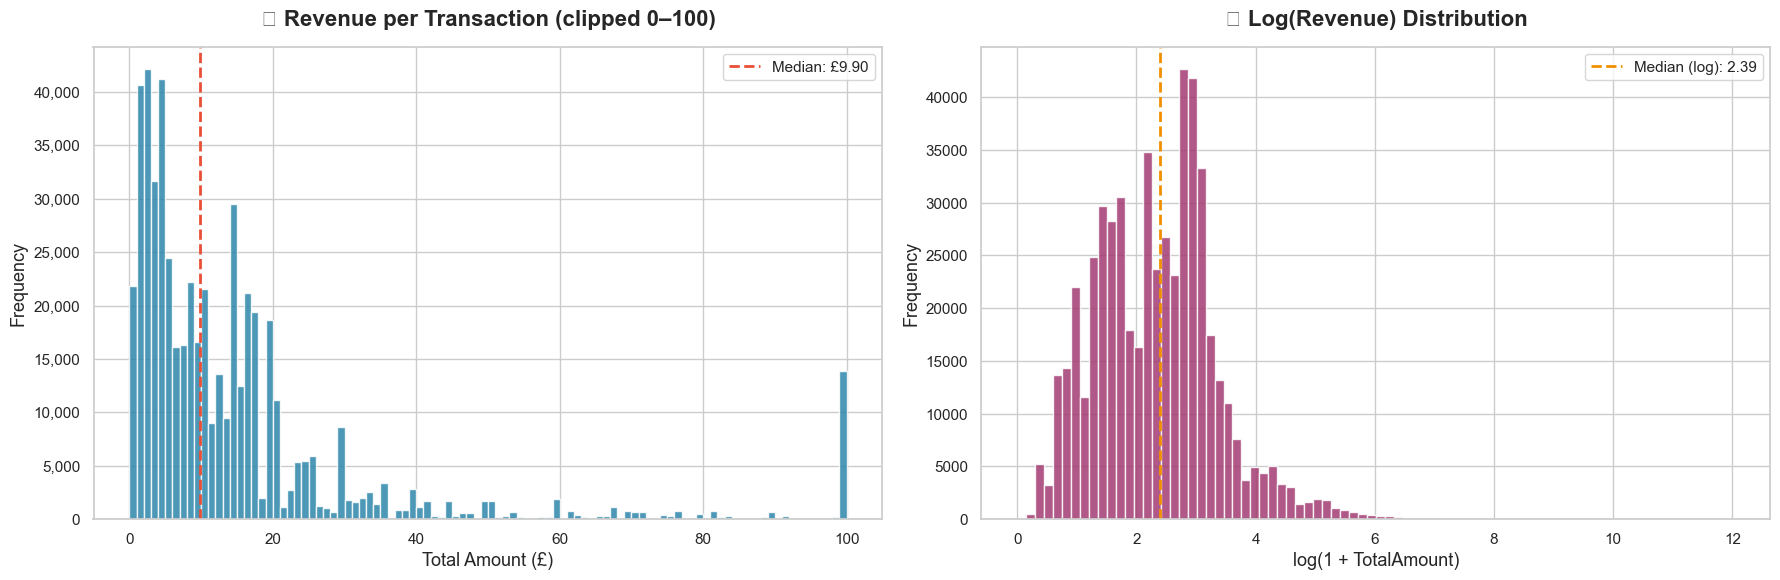

In [21]:
# ── Revenue Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# TotalAmount distribution (positive, clipped)
pos_amount = positive_txns['TotalAmount'].clip(0, 100)
axes[0].hist(pos_amount, bins=100, color='#2E86AB', edgecolor='white', alpha=0.85)
axes[0].axvline(positive_txns['TotalAmount'].median(), color='#E94F37', linestyle='--',
                lw=2, label=f'Median: £{positive_txns["TotalAmount"].median():.2f}')
axes[0].set_title('💰 Revenue per Transaction (clipped 0–100)', pad=15)
axes[0].set_xlabel('Total Amount (£)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Log distribution
log_amount = np.log1p(positive_txns['TotalAmount'])
axes[1].hist(log_amount, bins=80, color='#A23B72', edgecolor='white', alpha=0.85)
axes[1].axvline(log_amount.median(), color='#F18F01', linestyle='--',
                lw=2, label=f'Median (log): {log_amount.median():.2f}')
axes[1].set_title('📐 Log(Revenue) Distribution', pad=15)
axes[1].set_xlabel('log(1 + TotalAmount)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## 8️⃣ Summary Dashboard — Key Metrics at a Glance

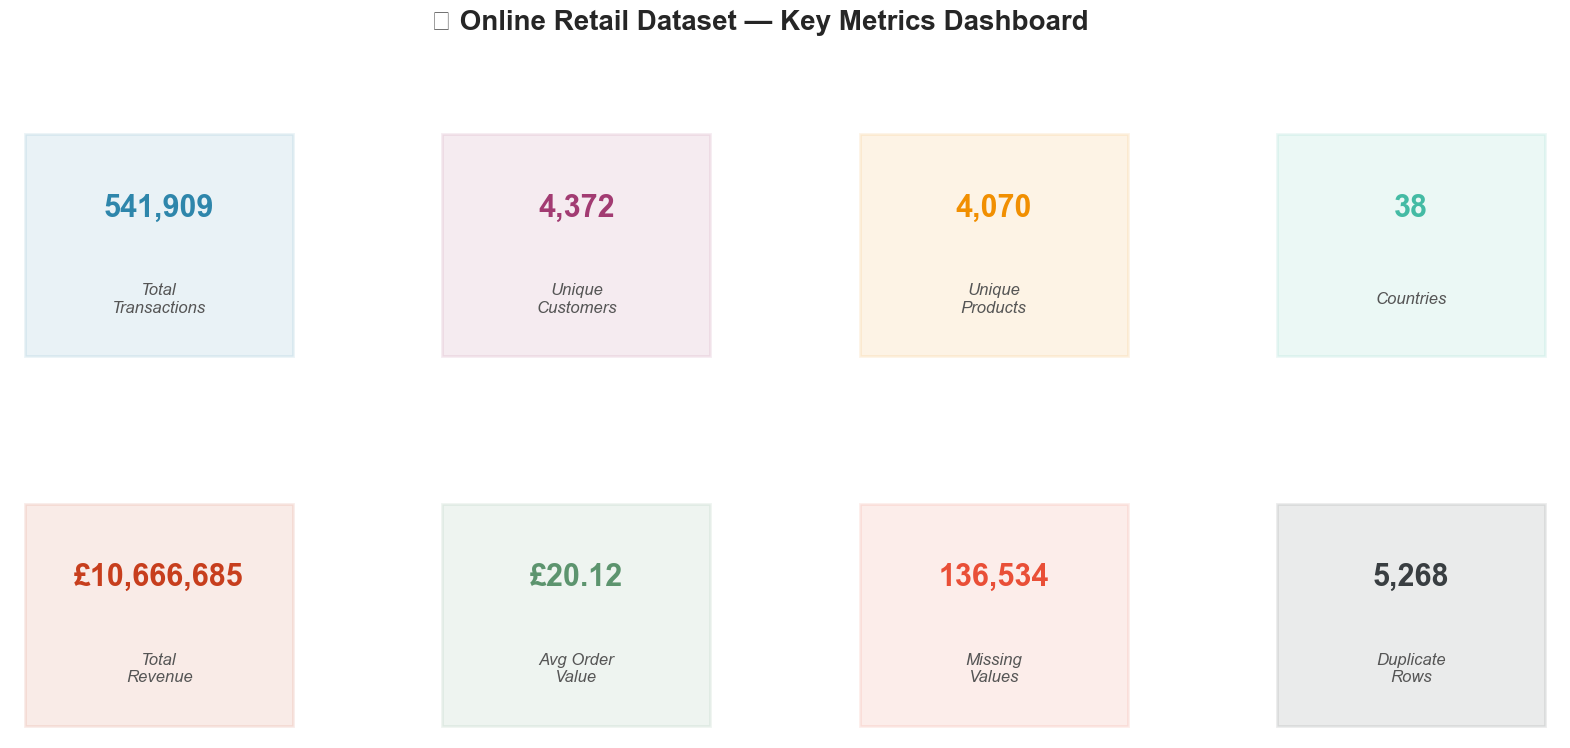

In [22]:
# ── Summary Dashboard ──
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# Key metrics
metrics = [
    ('Total\nTransactions', f'{len(dataset):,}', '#2E86AB'),
    ('Unique\nCustomers', f'{dataset["CustomerID"].nunique():,}', '#A23B72'),
    ('Unique\nProducts', f'{dataset["StockCode"].nunique():,}', '#F18F01'),
    ('Countries', f'{dataset["Country"].nunique()}', '#44BBA4'),
    ('Total\nRevenue', f'£{positive_txns["TotalAmount"].sum():,.0f}', '#C73E1D'),
    ('Avg Order\nValue', f'£{positive_txns["TotalAmount"].mean():.2f}', '#5C946E'),
    ('Missing\nValues', f'{dataset.isnull().sum().sum():,}', '#E94F37'),
    ('Duplicate\nRows', f'{dataset.duplicated().sum():,}', '#393E41'),
]

for i, (title, value, color) in enumerate(metrics):
    row, col = divmod(i, 4)
    ax = fig.add_subplot(gs[row, col])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Background rounded rectangle
    rect = plt.Rectangle((0.05, 0.05), 0.9, 0.9, linewidth=2,
                          edgecolor=color, facecolor=color, alpha=0.1,
                          transform=ax.transAxes, zorder=0)
    ax.add_patch(rect)
    
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.28, title, ha='center', va='center',
            fontsize=12, color='#555555', fontstyle='italic')
    ax.axis('off')

fig.suptitle('📊 Online Retail Dataset — Key Metrics Dashboard',
             fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

---
## 📋 Key Insights

| # | Insight |
|---|---|
| 1 | **United Kingdom dominates** — ~91% of all transactions originate from the UK |
| 2 | **~25% CustomerID missing** — these rows have no customer attribution |
| 3 | **~2% negative quantities** — cancelled/returned orders (InvoiceNo starts with 'C') |
| 4 | **~1% duplicate rows** — need to be removed before modeling |
| 5 | **Peak hours: 10 AM – 3 PM** — most transactions happen during business hours |
| 6 | **No Saturday data** — the store appears closed on Saturdays |
| 7 | **Revenue is right-skewed** — most transactions are small; a few very large ones |
| 8 | **Strong Quantity–TotalAmount correlation** — as expected, quantity drives revenue |
| 9 | **November spike** — likely driven by holiday/Black Friday shopping |
| 10 | **Top product: WHITE HANGING HEART T-LIGHT HOLDER** — most frequently purchased item |

---
### ✅ Next Steps
- **Preprocessing**: Remove duplicates, negative quantities, handle missing values
- **Feature Engineering**: Create RFM features, time-based features
- **Modeling**: Classification or clustering (customer segmentation)